In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA


df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header = None)
df.columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'species']

y = df['species']
x = df.drop('species', axis=1)


In [76]:
random_forest = RandomForestClassifier(max_depth=3, n_estimators=20)
random_forest.fit(x, y)

baseline_score = random_forest.score(x, y)
print(f"Random Forest Score: {baseline_score:.4f}")

Random Forest Score: 0.9667


In [77]:
n_values = [1, 2, 3, 4]
cumulative_variances = []
scores = []

print("PCA  Random Forest Results:")
print(f"{'n':<4} {'Explained Variance':<30} {'Model Score'}")

for n in n_values:
    pca = PCA(n_components=n)
    x_pca = pca.fit_transform(x)
    
    explained_var = np.sum(pca.explained_variance_ratio_)
    cumulative_variances.append(explained_var)
    rf_pca = RandomForestClassifier(max_depth=3, n_estimators=20)
    rf_pca.fit(x_pca, y)
    
    score = rf_pca.score(x_pca, y)
    scores.append(score)
    
    print(f"{n:<4} {explained_var * 100:.2f}% {score * 100:>30.2f}%")

PCA  Random Forest Results:
n    Explained Variance             Model Score
1    92.46%                          94.00%
2    97.76%                          95.33%
3    99.48%                          97.33%
4    100.00%                          97.33%


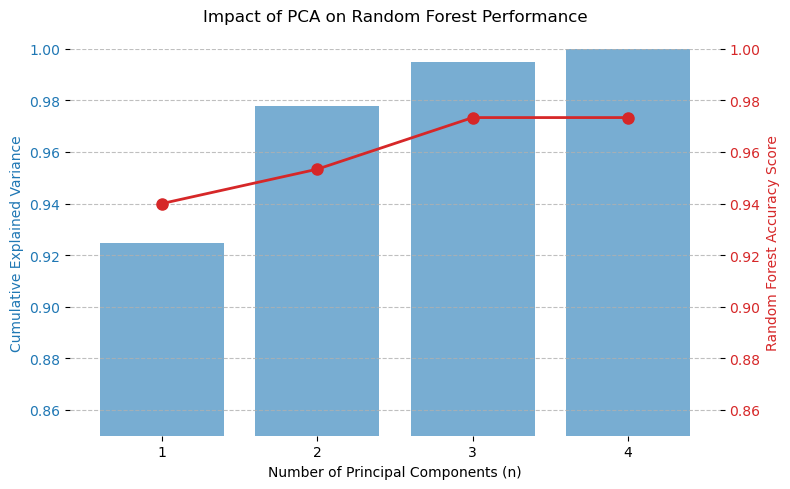

In [87]:
fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = 'tab:blue'
ax1.set_xlabel('Number of Principal Components (n)')
ax1.set_ylabel('Cumulative Explained Variance', color=color1)
ax1.bar(n_values, cumulative_variances, color=color1, alpha=0.6, label='Explained Variance')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0.85, 1.00) 
ax1.set_xticks(n_values)
ax2 = ax1.twinx()  

color2 = 'tab:red'
ax2.set_ylabel('Random Forest Accuracy Score', color=color2)  
ax2.plot(n_values, scores, color=color2, marker='o', linewidth=2, markersize=8, label='Accuracy Score')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0.85, 1.00) 

for spine in ax1.spines.values():
    spine.set_visible(False)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.title('Impact of PCA on Random Forest Performance', pad=20)
fig.tight_layout()  
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.show()

# Conclusions/Findings

Using a random forest approach with PCA modifications, we can see that using only 1 feature covers 92 percent of the variance present in the dataset. This explained variance increases to one hundred as the number of components reaches four (total amount of features in dataset). The positive trend is also present in the model score/accuracy which increases with the number of components. But a important conclusion can be drawn on the importance on using the last feature. Though the last feature does push us to cover all the varaince in the dataset, it doesnt improve the model score. Thus we can ignore that last feature to decrease our model size without impacting its performance in classification.

This is seen in the plot where the accuracy score plateaus at 97.33 percent from 3 features and onwards.